## Notebook 09: Model Evaluation

### 4 questions we answer
1. Horizon analysis — does error grow at 7, 14, 28 day forecasts?
2. Segment accuracy — which families does model handle best/worst?
3. Bias analysis — where is model systematically wrong?
4. Final comparison — LightGBM vs all baselines

### Why this matters
Overall SMAPE hides where the model works and where it fails.
A model with 47% overall SMAPE might be 20% on GROCERY I
and 90% on BABY CARE. Knowing this tells you where to improve.

In [1]:
# Load OOF predictions

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"]    = 100
sns.set_style("whitegrid")

def smape(y_true, y_pred):
    y_true = np.array(y_true, dtype=np.float32)
    y_pred = np.array(y_pred, dtype=np.float32)
    return 100 * np.mean(
        2 * np.abs(y_true - y_pred) /
        (np.abs(y_true) + np.abs(y_pred) + 1e-8)
    )

# Load OOF predictions
oof = pd.read_parquet("../outputs/oof_predictions.parquet")
print(f"OOF shape: {oof.shape}")
print(f"Columns: {oof.columns.tolist()}")
print(f"Date range: {oof['date'].min().date()} "
      f"to {oof['date'].max().date()}")
print(f"Folds: {oof['fold'].unique()}")

# Overall SMAPE check
overall = smape(oof["unit_sales"].values, oof["predicted"].values)
print(f"\nOverall OOF SMAPE: {overall:.2f}%")

OOF shape: (24944111, 7)
Columns: ['date', 'store_nbr', 'item_nbr', 'unit_sales', 'family', 'predicted', 'fold']
Date range: 2013-11-01 to 2017-08-14
Folds: [1 2 3 4 5]

Overall OOF SMAPE: 46.97%


In [2]:
# Horizon Analysis

# WHY: overall SMAPE hides how accuracy degrades over time
# A model predicting tomorrow is more accurate than
# predicting 28 days from now — this should always be true
# If it's not, something is wrong with our features

# For each date in OOF, compute how far it is from
# the training cutoff of its fold
fold_cutoffs = {}
df_dates = pd.read_parquet(
    "../data/features/model_ready.parquet",
    columns=["date"]
)
unique_dates = sorted(df_dates["date"].unique())
fold_size    = len(unique_dates) // 6

for fold in range(1, 6):
    cutoff = unique_dates[fold * fold_size - 1]
    fold_cutoffs[fold] = cutoff

print("Fold cutoff dates:")
for fold, cutoff in fold_cutoffs.items():
    print(f"  Fold {fold}: {pd.Timestamp(cutoff).date()}")

# Assign days_ahead to each OOF row
oof["cutoff"] = oof["fold"].map(fold_cutoffs)
oof["days_ahead"] = (
    pd.to_datetime(oof["date"]) -
    pd.to_datetime(oof["cutoff"])
).dt.days

print(f"\ndays_ahead range: "
      f"{oof['days_ahead'].min()} to {oof['days_ahead'].max()}")

Fold cutoff dates:
  Fold 1: 2013-10-31
  Fold 2: 2014-08-04
  Fold 3: 2015-05-08
  Fold 4: 2016-02-09
  Fold 5: 2016-11-10

days_ahead range: 1 to 277


 horizon  smape  rows
       1  46.44 81637
       2  46.77 81782
       3  45.21 83106
       4  46.16 82054
       5  46.47 81952
       6  46.50 81816
       7  47.32 81070
       8  46.75 82301
       9  45.88 83215
      10  45.42 83285
      11  45.98 83183
      12  46.56 82553
      13  46.44 81390
      14  47.23 80176
      15  46.78 81987
      16  45.61 83255
      17  45.93 83106
      18  46.40 83428
      19  46.22 82473
      20  46.36 82498
      21  46.91 83502
      22  46.64 85170
      23  45.50 86015
      24  45.76 87527
      25  47.93 87193
      26  45.93 87265
      27  46.96 85760
      28  48.25 88219


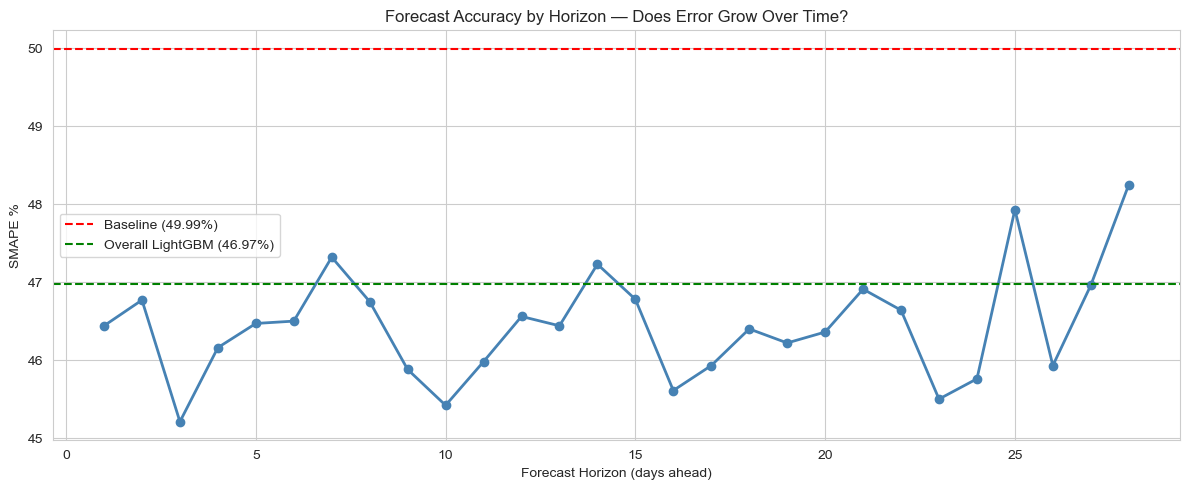


SMAPE at horizon 1:  46.44%
SMAPE at horizon 7:  47.32%
SMAPE at horizon 28: 48.25%


In [3]:
# Plot Horizon Analysis

# Compute SMAPE at each forecast horizon
horizon_results = []

for h in range(1, 29):
    mask = oof["days_ahead"] == h
    if mask.sum() < 100:
        continue
    h_smape = smape(
        oof.loc[mask, "unit_sales"].values,
        oof.loc[mask, "predicted"].values
    )
    horizon_results.append({
        "horizon": h,
        "smape":   round(h_smape, 2),
        "rows":    int(mask.sum())
    })

horizon_df = pd.DataFrame(horizon_results)
print(horizon_df.to_string(index=False))

# Plot
plt.figure(figsize=(12, 5))
plt.plot(
    horizon_df["horizon"],
    horizon_df["smape"],
    marker="o", color="steelblue", linewidth=2
)
plt.axhline(y=49.99, color="red", linestyle="--",
            label="Baseline (49.99%)")
plt.axhline(y=46.97, color="green", linestyle="--",
            label="Overall LightGBM (46.97%)")
plt.xlabel("Forecast Horizon (days ahead)")
plt.ylabel("SMAPE %")
plt.title("Forecast Accuracy by Horizon — Does Error Grow Over Time?")
plt.legend()
plt.tight_layout()
plt.savefig("../outputs/horizon_analysis.png", dpi=100)
plt.show()

print(f"\nSMAPE at horizon 1:  {horizon_df[horizon_df['horizon']==1]['smape'].values[0]:.2f}%")
print(f"SMAPE at horizon 7:  {horizon_df[horizon_df['horizon']==7]['smape'].values[0]:.2f}%")
print(f"SMAPE at horizon 28: {horizon_df[horizon_df['horizon']==28]['smape'].values[0]:.2f}%")

In [5]:
# WHY: family column was converted to category codes (0,1,2...)
# in the LightGBM notebook for model training
# We need to map codes back to names for readable analysis

# Load original family mapping
df_orig = pd.read_parquet(
    "../data/processed/master_sample.parquet",
    columns=["item_nbr", "family"]
)

# Build code → name mapping
family_map = (
    df_orig[["item_nbr","family"]]
    .drop_duplicates()
    .merge(
        oof[["item_nbr"]].drop_duplicates(),
        on="item_nbr"
    )
)

# Map family names back to OOF
oof = oof.merge(
    df_orig[["item_nbr","family"]]
    .drop_duplicates()
    .rename(columns={"family": "family_name"}),
    on="item_nbr",
    how="left"
)

print("Family mapping restored")
print(f"Sample family names: {oof['family_name'].dropna().unique()[:5]}")

Family mapping restored
Sample family names: <ArrowStringArray>
['GROCERY I', 'BREAD/BAKERY', 'DELI', 'CLEANING', 'POULTRY']
Length: 5, dtype: str


SMAPE by Product Family:
                    family  smape   bias    rows
                  HARDWARE  39.11  0.019   15271
                      EGGS  40.09 -0.005  337880
                AUTOMOTIVE  41.20  0.000   50285
           HOME APPLIANCES  41.65  0.032    5053
                    BEAUTY  41.77  0.057   40334
                   PRODUCE  41.83 -0.270 1724572
                   POULTRY  43.05 -0.081  434732
                   SEAFOOD  43.23  0.057   67114
            PREPARED FOODS  43.64 -0.226  159394
                     MEATS  44.13 -0.015  525196
              PET SUPPLIES  44.17  0.024   40568
                     DAIRY  44.56 -0.038 1925896
                 HOME CARE  45.30  0.041  608482
             PERSONAL CARE  45.39  0.023  897887
              BREAD/BAKERY  45.73 -0.088  932583
                      DELI  46.49  0.024  730335
   PLAYERS AND ELECTRONICS  46.54  0.024   56468
                 GROCERY I  47.16 -0.095 8597326
                 BABY CARE  47.46  0.131    

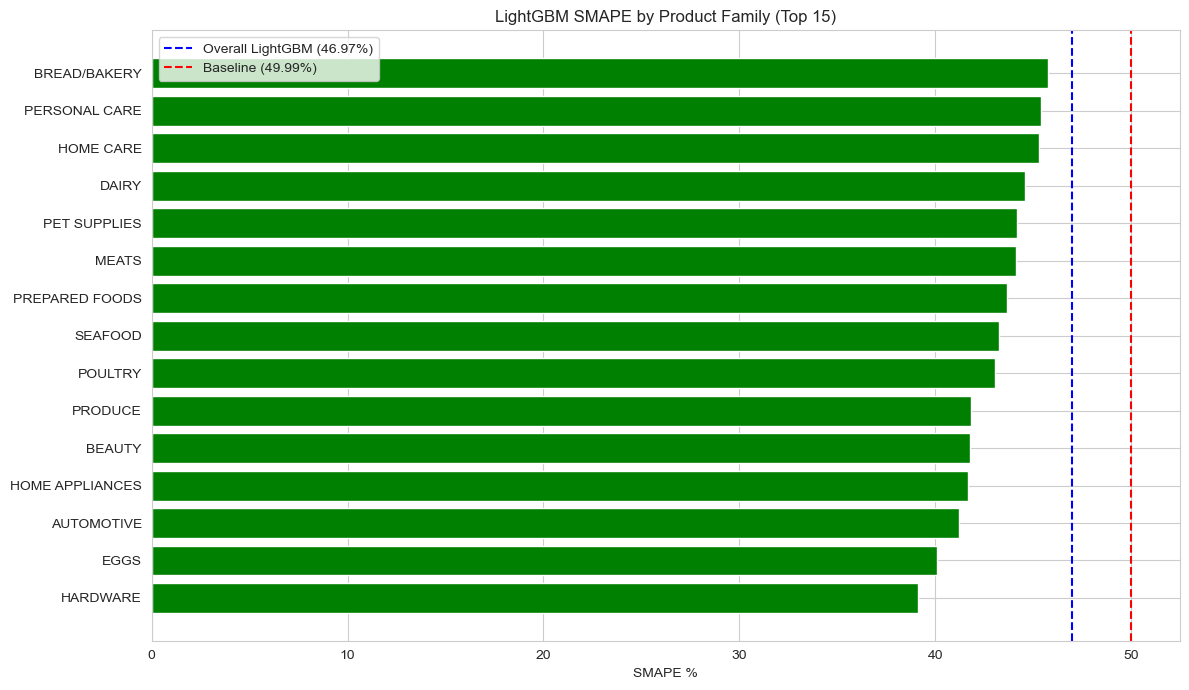

In [6]:
# Updated Cell 5 — uses family_name instead of family
family_results = []

for family in oof["family_name"].dropna().unique():
    mask = oof["family_name"] == family
    if mask.sum() < 50:
        continue
    f_smape = smape(
        oof.loc[mask, "unit_sales"].values,
        oof.loc[mask, "predicted"].values
    )
    f_bias = float(np.mean(
        oof.loc[mask, "predicted"].values -
        oof.loc[mask, "unit_sales"].values
    ))
    family_results.append({
        "family": family,
        "smape":  round(f_smape, 2),
        "bias":   round(f_bias,  3),
        "rows":   int(mask.sum())
    })

family_df = (
    pd.DataFrame(family_results)
    .sort_values("smape")
    .reset_index(drop=True)
)

print("SMAPE by Product Family:")
print(family_df.to_string(index=False))
print(f"\nBest:  {family_df.iloc[0]['family']} "
      f"({family_df.iloc[0]['smape']}%)")
print(f"Worst: {family_df.iloc[-1]['family']} "
      f"({family_df.iloc[-1]['smape']}%)")
print(f"\nGROCERY I: "
      f"{family_df[family_df['family']=='GROCERY I']['smape'].values[0]}%")

# Plot
plt.figure(figsize=(12, 7))
plot_df = family_df.head(15)
colors = [
    "green" if s < 46.97 else
    "orange" if s < 49.99 else
    "red"
    for s in plot_df["smape"]
]
plt.barh(plot_df["family"], plot_df["smape"], color=colors)
plt.axvline(x=46.97, color="blue", linestyle="--",
            label="Overall LightGBM (46.97%)")
plt.axvline(x=49.99, color="red", linestyle="--",
            label="Baseline (49.99%)")
plt.xlabel("SMAPE %")
plt.title("LightGBM SMAPE by Product Family (Top 15)")
plt.legend()
plt.tight_layout()
plt.savefig("../outputs/family_accuracy.png", dpi=100)
plt.show()

Bias Analysis:
Overall bias: -0.0975

Most under-forecasted (negative bias = stockout risk):
          family   bias  smape
    FROZEN FOODS -0.475  47.76
         PRODUCE -0.270  41.83
      GROCERY II -0.233  53.13
  PREPARED FOODS -0.226  43.64
LIQUOR,WINE,BEER -0.192  55.31

Most over-forecasted (positive bias = overstock risk):
                    family  bias  smape
                   SEAFOOD 0.057  43.23
                    BEAUTY 0.057  41.77
SCHOOL AND OFFICE SUPPLIES 0.064  48.88
                 BABY CARE 0.131  47.46
                     BOOKS 0.141  48.07


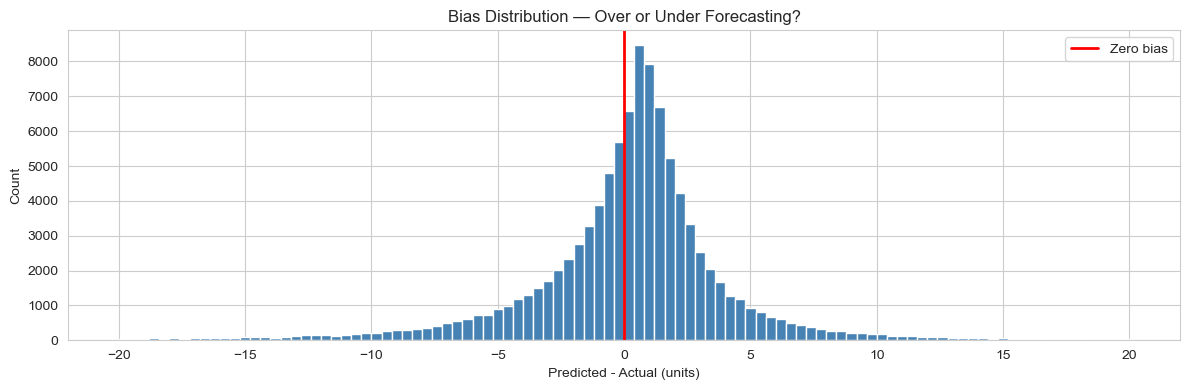

In [7]:
# Bias Analysis
print("Bias Analysis:")
print(f"Overall bias: "
      f"{float(np.mean(oof['predicted'] - oof['unit_sales'])):.4f}")
print()

bias_df = family_df.sort_values("bias")
print("Most under-forecasted (negative bias = stockout risk):")
print(bias_df.head(5)[["family","bias","smape"]].to_string(
    index=False))
print()
print("Most over-forecasted (positive bias = overstock risk):")
print(bias_df.tail(5)[["family","bias","smape"]].to_string(
    index=False))

# Bias histogram
plt.figure(figsize=(12, 4))
sample_bias = (
    oof["predicted"] - oof["unit_sales"]
).sample(100000, random_state=42)
plt.hist(sample_bias, bins=100, color="steelblue",
         edgecolor="white", range=(-20, 20))
plt.axvline(x=0, color="red", linewidth=2, label="Zero bias")
plt.xlabel("Predicted - Actual (units)")
plt.ylabel("Count")
plt.title("Bias Distribution — Over or Under Forecasting?")
plt.legend()
plt.tight_layout()
plt.savefig("../outputs/bias_distribution.png", dpi=100)
plt.show()

In [8]:
# Complete comparison of all approaches

comparison = {
    "Seasonal Naive":     {"smape": 81.94, "notes": "lag_7, fails on sparse items"},
    "Moving Average 28d": {"smape": 49.99, "notes": "rolling_mean_28, strong baseline"},
    "SARIMA (3 series)":  {"smape": 54.40, "notes": "avg of 3 series, 229hrs for all"},
    "LightGBM Global":    {"smape": 46.97, "notes": "global model, minutes to train"},
}

print("=" * 65)
print("FINAL MODEL COMPARISON")
print("=" * 65)
print(f"{'Model':<25} {'SMAPE':>8}  {'Notes'}")
print("-" * 65)
for model, data in comparison.items():
    marker = " ← BEST" if data["smape"] == min(
        v["smape"] for v in comparison.values()
    ) else ""
    print(f"{model:<25} {data['smape']:>7.2f}%  "
          f"{data['notes']}{marker}")
print("=" * 65)
print(f"\nLightGBM beats Moving Average by: "
      f"{49.99 - 46.97:.2f}% SMAPE")
print(f"LightGBM beats Seasonal Naive by: "
      f"{81.94 - 46.97:.2f}% SMAPE")

FINAL MODEL COMPARISON
Model                        SMAPE  Notes
-----------------------------------------------------------------
Seasonal Naive              81.94%  lag_7, fails on sparse items
Moving Average 28d          49.99%  rolling_mean_28, strong baseline
SARIMA (3 series)           54.40%  avg of 3 series, 229hrs for all
LightGBM Global             46.97%  global model, minutes to train ← BEST

LightGBM beats Moving Average by: 3.02% SMAPE
LightGBM beats Seasonal Naive by: 34.97% SMAPE


In [9]:
import joblib
import numpy as np

# Load final model and feature store
final_model = joblib.load("../outputs/models/lightgbm_final.pkl")
df_features = pd.read_parquet(
    "../data/features/model_ready.parquet"
)

# Get last 28 days as forecast period
FEATURE_COLS = [
    "lag_1", "lag_7", "lag_14", "lag_28",
    "rolling_mean_7", "rolling_mean_28", "rolling_std_7",
    "day_of_week", "month", "is_weekend",
    "day_of_month", "week_of_year",
    "oil_price", "oil_price_change_pct", "discount_depth",
    "is_holiday", "cluster", "perishable",
    "family_store_mean"
]

# Convert categories to codes same as training
for col in ["family", "city", "state", "type"]:
    if col in df_features.columns:
        df_features[col] = (
            df_features[col].astype("category").cat.codes.astype("int8")
        )

cutoff = df_features["date"].max() - pd.Timedelta(days=28)
forecast_input = df_features[
    df_features["date"] > cutoff
].copy()

# Generate point predictions
preds = final_model.predict(forecast_input[FEATURE_COLS])
preds = np.clip(preds, 0, None)

# Compute confidence intervals using OOF RMSE
oof = pd.read_parquet("../outputs/oof_predictions.parquet")
rmse_overall = float(np.sqrt(
    np.mean((oof["predicted"] - oof["unit_sales"])**2)
))
z = 1.28  # 90% confidence interval

forecast_output = forecast_input[[
    "date", "store_nbr", "item_nbr",
    "unit_sales"
]].copy()

# Add family names back
df_orig = pd.read_parquet(
    "../data/processed/master_sample.parquet",
    columns=["item_nbr", "family"]
).drop_duplicates()
forecast_output = forecast_output.merge(
    df_orig, on="item_nbr", how="left"
)

forecast_output["predicted"]    = preds
forecast_output["lower_bound"]  = np.clip(
    preds - z * rmse_overall, 0, None
)
forecast_output["upper_bound"]  = preds + z * rmse_overall
forecast_output["model"]        = "lightgbm"

# Save
forecast_output.to_parquet(
    "../outputs/forecasts/forecast_table.parquet",
    index=False
)

print(f"Forecast table saved: {forecast_output.shape}")
print(f"Date range: {forecast_output['date'].min().date()} "
      f"to {forecast_output['date'].max().date()}")
print(f"Confidence interval width: ±{z * rmse_overall:.2f} units")
print(f"\nSample:")
print(forecast_output.head(3)[[
    "date","store_nbr","family",
    "unit_sales","predicted","lower_bound","upper_bound"
]])

Forecast table saved: (600090, 9)
Date range: 2017-07-19 to 2017-08-15
Confidence interval width: ±18.19 units

Sample:
        date  store_nbr     family  unit_sales  predicted  lower_bound  \
0 2017-07-21          1  GROCERY I         3.0   1.415832          0.0   
1 2017-07-22          1  GROCERY I         2.0   1.448057          0.0   
2 2017-07-31          1  GROCERY I         2.0   1.428501          0.0   

   upper_bound  
0    19.608325  
1    19.640550  
2    19.620995  
